In [462]:
import importlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# adjust path
path_to_hkpt = '../'
import sys
sys.path.append(path_to_hkpt)

import hk_parallel_transport as hkpt
hkpt = importlib.reload(hkpt)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


In [475]:
n_1 = 1000
n_2 = 1000
n_3 = 1000

mean_1 = np.array([0.0])
cov_1 = np.array([[3.0]])
mean_2 = np.array([25.0])
cov_2 = np.array([[3.0]])
mean_3 = np.array([40.0])
cov_3 = np.array([[3.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = (np.pi / 4) / max(abs(max_val), abs(min_val))
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

Scaled mean_1: [0.], Scaled sigma_1: 0.030282320247786838
Scaled mean_2: [0.43708764], Scaled sigma_2: 0.030282320247786838
Scaled mean_3: [0.69934023], Scaled sigma_3: 0.030282320247786838


In [480]:
mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_23 = hkpt.hk_logarithmic_map(
    mu2,
    mu3, 
    allow_approximation=True, 
    approximation_mode='barycentric',
    let_solver='pot_sinkhorn',
    entropy_reg=1e-3,
)

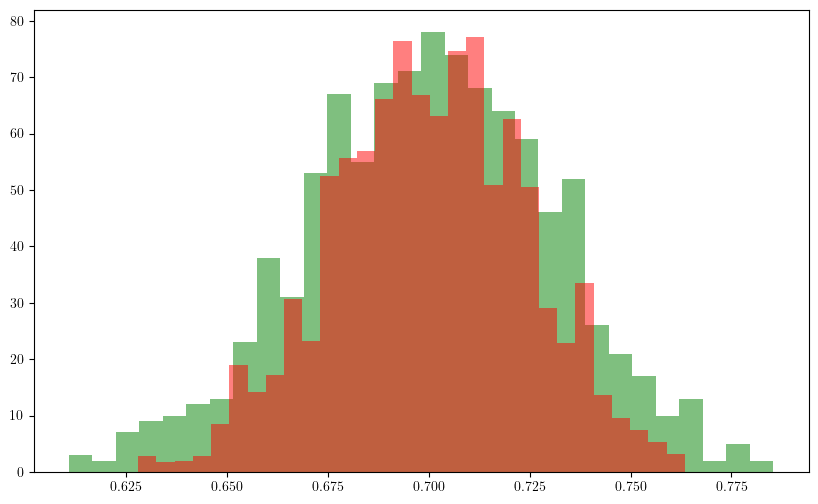

In [481]:
# diagnostic: plot mu3 and \hat mu3 = exp(log(mu2, mu3)) on the same plot
mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23)
plt.figure(figsize=(10, 6))
plt.hist(data_3.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu2}(\mu_3))$', color='red', alpha=0.5);

In [482]:
# print mean and var of mu3 and mu3_at_mu2 locations (not weights)
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.mean((mu3_at_mu2.samples.flatten() - np.mean(mu3_at_mu2.samples.flatten() ))**2 ) ** 0.5}")

mu3 mean: 0.7003690350792073, mu3 var: 0.03060862499418711
mu3_at_mu2 mean: 0.6995751795865159, mu3_at_mu2 var: 0.02388341269637877


In [487]:
# parallel transport tangent_23 from mu2 to mu1
tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu2,
    mu1,
    tangent_23,
    N = 5,
    return_alignment_diagnostics=True,
    approximation_mode='barycentric',
    let_solver='pot_sinkhorn',
    entropy_reg=1e-3,
    alignment_tol=0.2,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1)


Transporting step 1/5...


Transporting step 2/5...


Transporting step 3/5...


Transporting step 4/5...


Transporting step 5/5...


Parallel transport alignment succeeded


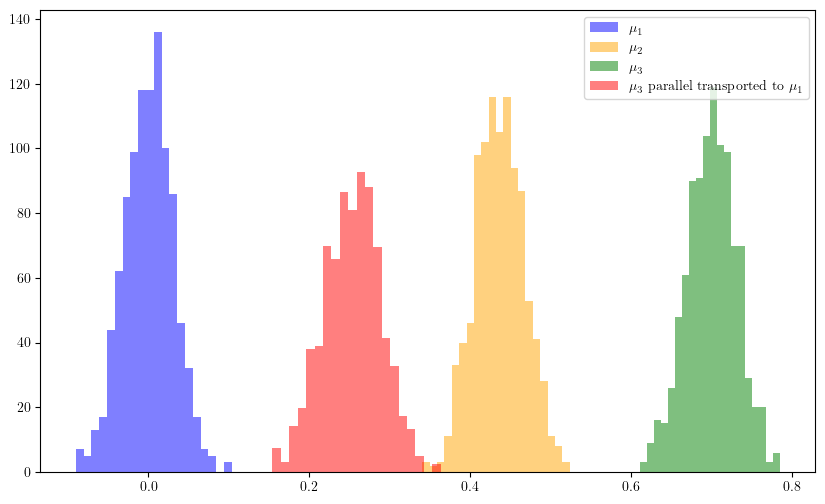

In [488]:
# plot all four measures on the same plot as unnormalized histograms with weights from the empirical measures
plt.figure(figsize=(10, 6))
plt.hist(data_1.flatten(), bins=20, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
plt.hist(data_2.flatten(), bins=20, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
plt.hist(data_3.flatten(), bins=20, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
if mu3_at_mu1 is not None:
    plt.hist(mu3_at_mu1.samples.flatten(), bins=20, weights=mu3_at_mu1.weights, label=r'$\mu_3$ parallel transported to $\mu_1$', color='red', alpha=0.5);
plt.legend()


In [489]:
# print total mass
print(f"Total mass of mu1: {np.sum(mu1.weights)}")
print(f"Total mass of mu2: {np.sum(mu2.weights)}")
print(f"Total mass of mu3: {np.sum(mu3.weights)}")
print(f"Total mass of mu3_at_mu1: {np.sum(mu3_at_mu1.weights)}")

Total mass of mu1: 1000.0
Total mass of mu2: 1000.0
Total mass of mu3: 1000.0
Total mass of mu3_at_mu1: 787.0143190334131


Transporting step 1/5...


Transporting step 2/5...


Transporting step 3/5...


Transporting step 4/5...


Transporting step 5/5...


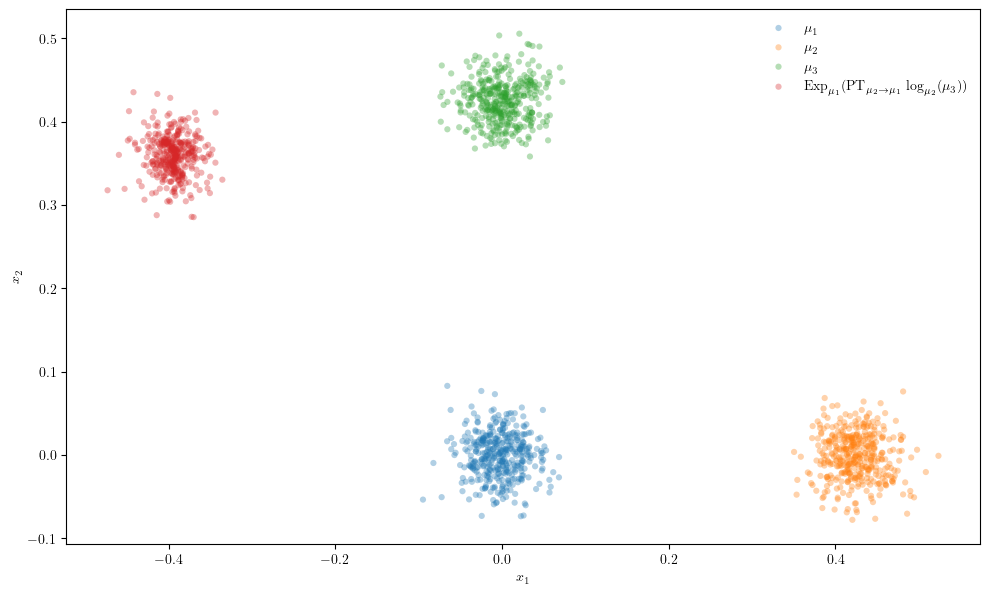

In [473]:
# 2D Gaussian experiment: parallel transport mu3 to the tangent space at mu1,
# then push forward with the empirical HK exponential map.
n_1_2d = 400
n_2_2d = 400
n_3_2d = 400

mean_1_2d = np.array([0.0, 0.0])
cov_1_2d = np.array([[0.1, 0.0], [0.0, 0.1]])
mean_2_2d = np.array([5.0, 0.0])
cov_2_2d = np.array([[0.1, 0.0], [0.0, 0.1]])
mean_3_2d = np.array([0.0, 5.0])
cov_3_2d = np.array([[0.1, 0.0], [0.0, 0.1]])

rng_2d = np.random.default_rng(1)
data_1_2d = rng_2d.multivariate_normal(mean_1_2d, cov_1_2d, n_1_2d)
data_2_2d = rng_2d.multivariate_normal(mean_2_2d, cov_2_2d, n_2_2d)
data_3_2d = rng_2d.multivariate_normal(mean_3_2d, cov_3_2d, n_3_2d)

# Scale all samples so pairwise distances stay comfortably inside the HK cone regime.
all_data_2d = np.vstack([data_1_2d, data_2_2d, data_3_2d])
max_radius_2d = np.max(np.linalg.norm(all_data_2d, axis=1))
scale_factor_2d = (np.pi / 6) / max_radius_2d
data_1_2d *= scale_factor_2d
data_2_2d *= scale_factor_2d
data_3_2d *= scale_factor_2d

mu1_2d = hkpt.EmpiricalMeasure(data_1_2d, weights=np.ones(n_1_2d))
mu2_2d = hkpt.EmpiricalMeasure(data_2_2d, weights=np.ones(n_2_2d))
mu3_2d = hkpt.EmpiricalMeasure(data_3_2d, weights=np.ones(n_3_2d))

tangent_23_2d = hkpt.hk_logarithmic_map(
    mu2_2d,
    mu3_2d,
    allow_approximation=True,
    approximation_mode='barycentric',
    let_solver='pot_sinkhorn',
    entropy_reg=1e-3,
)

tangent_23_at_mu1_2d, pt_alignment_diag_2d = hkpt.hk_parallel_transport(
    mu2_2d,
    mu1_2d,
    tangent_23_2d,
    compression_max_atoms=6000,
    compression_kmeans_iterations=50,
    approximation_mode='barycentric',
    return_alignment_diagnostics=True,
    alignment_tol=0.12,
    N = 5,
)

if tangent_23_at_mu1_2d is not None:
    mu3_at_mu1_2d = hkpt.hk_exponential_map(mu1_2d, tangent_23_at_mu1_2d)
else:
    mu3_at_mu1_2d = hkpt.EmpiricalMeasure(
        pt_alignment_diag_2d['transported_support'],
        np.ones(len(pt_alignment_diag_2d['transported_support'])),
    )

measures_2d = [
    (mu1_2d, r'$\mu_1$', '#1f77b4'),
    (mu2_2d, r'$\mu_2$', '#ff7f0e'),
    (mu3_2d, r'$\mu_3$', '#2ca02c'),
    (mu3_at_mu1_2d, r'$\mathrm{Exp}_{\mu_1}(\mathrm{PT}_{\mu_2\to\mu_1}\,\log_{\mu_2}(\mu_3))$', '#d62728'),
]

fig, ax = plt.subplots(figsize=(10, 8))
for measure, label, color in measures_2d:
    ax.scatter(
        measure.samples[:, 0],
        measure.samples[:, 1],
        s=20,
        alpha=0.35,
        color=color,
        edgecolors='none',
        label=label,
    )

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)

if not pt_alignment_diag_2d['alignment_succeeded']:
    ax.set_title('2D HK experiment (red cloud uses transported support; final alignment failed)')

plt.tight_layout()
plt.show()


In [474]:
# print total mass of each measure in the 2D experiment
for measure, label, color in measures_2d:
    print(f"Total mass of {label}: {np.sum(measure.weights)}")

Total mass of $\mu_1$: 400.0
Total mass of $\mu_2$: 400.0
Total mass of $\mu_3$: 400.0
Total mass of $\mathrm{Exp}_{\mu_1}(\mathrm{PT}_{\mu_2\to\mu_1}\,\log_{\mu_2}(\mu_3))$: 545.0423673249495


In [450]:
print("mu_1.samples\n", mu1_2d.samples[0:3])
print()
print("mu2.samples\n", mu2_2d.samples[0:3])
print()
print("mu3.samples\n", mu3_2d.samples[0:3])
print()
print("mu3_at_mu1.samples\n", mu3_at_mu1_2d.samples[0:3])
print()
print("tangent_23_2d.directions\n", tangent_23_at_mu1_2d[0][0:3])
print()
print("original tangent.directions\n", tangent_23_2d[0][0:3])


mu_1.samples
 [[ 0.00924945  0.02199034]
 [ 0.00884404 -0.03487857]
 [ 0.02423155  0.01194707]]

mu2.samples
 [[ 0.40451887 -0.00271501]
 [ 0.35336003 -0.047551  ]
 [ 0.44684129  0.00920792]]

mu3.samples
 [[-0.00919797  0.43968766]
 [-0.01646789  0.4135907 ]
 [-0.00226881  0.41094189]]

mu3_at_mu1.samples
 [[-0.00318061 -0.00048435]
 [-0.00330467 -0.00055217]
 [-0.00306798 -0.00048771]]



TypeError: 'NoneType' object is not subscriptable